# Imports

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../utils"))  # repo utils/ (vendored sweep + shared helpers)
file_path = '../data/raw_sweeps' # add path to data 

from utils import update_rc_params

In [2]:
from sweep import sweep_load as sl
import numpy as np
import numpy.matlib
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
import h5py
import cmasher as cmr
import pandas as pd

from matplotlib.gridspec import GridSpec
from matplotlib.ticker import SymmetricalLogLocator
import matplotlib.lines as mlines

import sys
sys.path.append("../utils")
from utils import *

# Physical constants
h = 6.626E-34  # Planck constant (J·s)
e = 1.6002E-19  # Elementary charge (C)
phi0 = h / e    # Flux quantum (Wb)
Rq = h/e**2
from matplotlib.gridspec import GridSpecFromSubplotSpec

In [3]:
update_rc_params('talk')

In [4]:
dtg=rmg19['default']['dtg']
print(dtg)

17.406


# Helper functions for FFT analysis

In [5]:
class Lf_analysis:
    def __init__(self, file, contact, is_exp_data=True):
        if is_exp_data:
            data = sl.pload(file_path, file)
            self.B_raw = data['ys'][0]
            self.Rxx_raw = data[f'sr830_{contact}_X']/data['sr830_4_X']
            Vtgs = data['xs'][0]
            Vbgs = data['xs'][1]
            self.density, _ = calculate_n_D(Vtgs, Vbgs, dtg=rmg19['default']['dtg'], dbg=rmg19['default']['dbg'])
        else:
            self.data = load_LL_simulation_data(file)
            self.density = self.data["ns_lin"][1:] # remove zero density
            fluxes = self.data["fluxes"]
            self.B_raw = np.array([78912.31601883237*phi[0]/phi[1] for phi in fluxes])
            self.Rxx_raw = self.data["rhos_single_particle"][:,1:] # remove zero density
            
    # @lru_cache(maxsize=1)

    def get_bg_subtracted_data(self, bg_method, bg_method_params, blims, return_bg=False):
        """ 
            Do background subtraction on data 
            bg_method is function that takes in a row in B, Rxx and subtracts it
            blims is (low, high) bounds for B
        """
        # Limit our B
        blo, bhi = blims
        bmask = (blo < self.B_raw) & (self.B_raw < bhi)
        bflat = np.abs(np.diff(self.B_raw[bmask])) > 0 # get rid of parts where b is flat
        bmask[bmask] = bmask[bmask] & np.append(bflat, 1) & np.insert(bflat, 0, 1)
        B = self.B_raw[bmask] 
        Rxx_raw = self.Rxx_raw[bmask]    
        # Do a background subtraction on each line
        Rxx_detrended = np.zeros_like(Rxx_raw)
        for i, cut in enumerate(Rxx_raw.T):
            Rxx_detrended[:,i], _ = bg_method(B, cut, **bg_method_params)
        if return_bg:
            return B, Rxx_detrended, Rxx_raw - Rxx_detrended
        return B, Rxx_detrended

    # @lru_cache(maxsize=10)

    def get_fft(self, bg_method, bg_method_params, padding, blims, num_pts_max=5000):
        B, Rxx_detrended = self.get_bg_subtracted_data(bg_method, bg_method_params, blims)
        invB_range = np.max(1/B) - np.min(1/B)
        num_invB_pts = int(np.ceil(invB_range / np.min(np.abs(np.diff(1/B)))))
        if num_invB_pts > num_pts_max:
            num_invB_pts = num_pts_max
        ffts = np.zeros((int(num_invB_pts*(2*padding+1)/2), len(self.density)), dtype=complex)
        freqs = np.zeros((int(num_invB_pts*(2*padding+1)/2), len(self.density)))
        for i, cut in enumerate(Rxx_detrended.T):
            interp_invB, interp_cut = interp_rxx(B, cut, nx=num_invB_pts, type='cubic')
            fft, freq = make_vec_fft(interp_invB, interp_cut, n=self.density[i], padding=padding, return_complex=True)
            ffts[:,i] = fft[:len(freq)//2]
            freqs[:,i] = freq[:len(freq)//2]

        return ffts, freqs
    
    def get_fft_line(self, target_density, bg_method, bg_method_params, padding, blims):
        # As get fft, but only get one line in density
        density_idx = np.argmin(np.abs(self.density-target_density))
        blo, bhi = blims
        bmask = (blo < self.B_raw) & (self.B_raw < bhi)
        bflat = np.abs(np.diff(self.B_raw[bmask])) > 0 # get rid of parts where b is flat
        bmask[bmask] = bmask[bmask] & np.append(bflat, 1) & np.insert(bflat, 0, 1)
        B = self.B_raw[bmask] 
        Rxx_raw = self.Rxx_raw[bmask, density_idx]        
        Rxx_detrended, _ = bg_method(B, Rxx_raw, **bg_method_params)
        invB_range = np.max(1/B) - np.min(1/B)
        num_invB_pts = int(np.ceil(invB_range / np.min(np.abs(np.diff(1/B)))))
        interp_invB, interp_cut = interp_rxx(B, Rxx_detrended, nx=num_invB_pts, type='cubic')
        psd, freq = make_vec_fft(interp_invB, interp_cut, n=self.density[density_idx], padding=padding, normalize=False)
        psd = psd[:len(freq)//2]
        freq = freq[:len(freq)//2]
        return psd, freq

    @staticmethod
    def get_fft_peak(freq, fft, target_peak_val):
        # Given a cut in freq and peak, find peaks most closely matching target_peak_vals
        peaks, _ = find_peaks(np.abs(fft)**2, prominence=0.1)
        if len(peaks) < 1:
            return np.nan, np.nan
    
        peak_v = peaks[np.argmin(np.abs(freq[peaks] - target_peak_val))]
        
        return fft[peak_v], freq[peak_v]

    def plot_blim_effect(self, fig, ax, norm, bg_method, bg_method_params, padding, bhi_max, blo_min, target_density, target_freq, n_B_lims=60):
        min_window_len = 0.2

        b_mins = np.linspace(blo_min, 2.0, num=n_B_lims)
        b_maxes = np.linspace(blo_min+min_window_len, bhi_max, num=n_B_lims)

        fft_coefs_out = np.zeros((n_B_lims, n_B_lims)) * np.nan
        freqs_out = np.zeros((n_B_lims, n_B_lims)) * np.nan

        density_val = self.density[np.argmin(np.abs(self.density-target_density))]        
        for j, blo in enumerate(b_mins):
            for k, bhi in enumerate(b_maxes):
                if bhi - blo < min_window_len:
                    # Skip windows that are too small
                    fft_coefs_out[j,k], freqs_out[j,k] = np.nan, np.nan
                    continue
                
                psds, freqs = self.get_fft_line(target_density, bg_method, bg_method_params, padding, blims=(blo, bhi))
                fft, freq = self.get_fft_peak(freqs, psds, target_freq)
                fft_coefs_out[j,k], freqs_out[j,k] = np.abs(fft)**2, freq
        
        ax.set_facecolor('k')
        plot = ax.pcolormesh(
            b_mins, b_maxes, freqs_out.T*density_val,  rasterized=True,
            norm=norm, cmap='RdBu_r'
        )
        
        ax.set_xlabel("Low field cutoff (T)")
        ax.set_ylabel("High field cutoff (T)")
        return plot
    
    def plot_bw_filter_effect(self, fig, ax, norm, padding, target_density, target_freq, n_filters=60):
        min_window_len = 0.2

        filters = np.linspace(0, 50.0, num=n_filters)
        orders = np.arange(7, dtype=int)

        fft_coefs_out = np.zeros((n_filters, 7)) * np.nan
        freqs_out = np.zeros((n_filters, 7)) * np.nan

        density_val = self.density[np.argmin(np.abs(self.density-target_density))]        
        for j, filter_cutoff in enumerate(filters):
            for k, order in enumerate(orders):
              
                psds, freqs = self.get_fft_line(target_density, detrend_butterworth, {'cutoff': filter_cutoff, 'order': order}, padding, blims=(0.62, 4.98))
                fft_coefs_out[j,k], freqs_out[j,k] = self.get_fft_peak(freqs, psds, target_freq)
        
        ax.set_facecolor('k')
        plot = ax.pcolormesh(
            filters, orders, freqs_out.T*density_val,  rasterized=True,
            norm=norm, cmap='RdBu_r'
        )
        
        ax.set_xlabel(r"Filter Cutoff ($T^{-1}$)")
        ax.set_ylabel("Filter Order")
        return plot

    def plot_fft(self, fig, ax, norm, bg_method, bg_method_params, padding, blims=(0.51, 2.49), target_density=None):
        ffts, freqs = self.get_fft(bg_method, bg_method_params, padding, blims)
        psds = np.abs(ffts)**2
        density_repeated = np.tile(self.density, (freqs.shape[0], 1))
        if norm is None:
            # Default to lognorm
            norm = colors.LogNorm(vmin=np.quantile(psds,0.2), vmax=np.quantile(psds,0.99))

        plot = ax.pcolormesh(density_repeated, freqs, psds, norm=norm, cmap='viridis', rasterized=True, lw=0)
        ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
        ax.set_ylabel(r'$f/(nh/e)$')
        ax.set_ylim(0, 3)

        if target_density is not None:
            density_idx = np.argmin(np.abs(target_density-self.density))
            ax.vlines(self.density[density_idx], 0, 2, 'r', linestyle='dashed', alpha=0.8, lw=2)
            psd, freq = psds[:,density_idx], freqs[:,density_idx]
            target_peaks = np.array([1.155, 0.925])/self.density[density_idx]
            for peak in target_peaks:
                p, f = self.get_fft_peak(freq, psd, peak)
                print(f)

        return plot
    
    def plot_fft_invcm(self, fig, ax, norm, bg_method, bg_method_params, padding, blims=(0.51, 2.49), target_density=None):
        ffts, freqs = self.get_fft(bg_method, bg_method_params, padding, blims)
        
        density_repeated = np.tile(self.density, (freqs.shape[0], 1))
        if norm is None:
            # Default to lognorm
            norm = colors.LogNorm(vmin=np.quantile(psds,0.2), vmax=np.quantile(psds,0.99))
        # Grey out freq cutoff
        psds = np.abs(ffts)**2
        plot = ax.pcolormesh(density_repeated, freqs*density_repeated, psds, norm=norm, cmap='viridis', rasterized=True, lw=0)
        
        ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
        ax.set_ylabel(r'$f/(h/e)$ ($10^{12}$ cm$^{-2}$)')
        ax.set_ylim(0, 2)

        if target_density is not None:
            density_idx = np.argmin(np.abs(target_density-self.density))
            ax.vlines(self.density[density_idx], 0, 2, 'r', linestyle='dashed', alpha=0.8, lw=2)
            psd, freq =  psds[:,density_idx], freqs[:,density_idx]
            target_peaks = np.array([1.155, 0.925])/self.density[density_idx]
            for peak in target_peaks:
                p, f = self.get_fft_peak(freq, psd, peak)
                print(f*self.density[density_idx])
         
        return plot

    def plot_fft_invcm_phase(self, fig, ax, norm, bg_method, bg_method_params, padding, blims=(0.51, 2.49), target_density=None):
        ffts, freqs = self.get_fft(bg_method, bg_method_params, padding, blims)
        angles = np.angle(ffts, deg=True) %180
        density_repeated = np.tile(self.density, (freqs.shape[0], 1))
        if norm is None:
            # Default to lognorm
            norm = colors.Normalize(vmin=0, vmax=180)

        plot = ax.pcolormesh(density_repeated, freqs*density_repeated, angles, norm=norm, cmap='twilight', rasterized=True, lw=0)
        ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
        ax.set_ylabel(r'$f/(h/e)$ ($10^{12}$ cm$^{-2}$)')
        ax.set_ylim(0, 2)

        if target_density is not None:
            density_idx = np.argmin(np.abs(target_density-self.density))
            ax.vlines(self.density[density_idx], 0, 2, 'r', linestyle='dashed', alpha=0.8, lw=2)
            psd, freq =  angles[:,density_idx], freqs[:,density_idx]
            target_peaks = np.array([1.155, 0.925])/self.density[density_idx]
            for peak in target_peaks:
                p, f = self.get_fft_peak(freq, psd, peak)
                print(f*self.density[density_idx])
         
        return plot

    def plot_fft_grad(self, fig, ax, norm, bg_method, bg_method_params, padding, blims=(0.51, 2.49)):
        ffts, freqs = self.get_fft(bg_method, bg_method_params, padding, blims)
        psds = np.abs(ffts)**2
        density_repeated = np.tile(self.density, (freqs.shape[0], 1))
        # def fft_deriv(linecut):
        #     # derivative down to a constant
        #     N = 6*len(linecut)
        #     fft = scipy.fft.rfft(linecut, n=N)
        #     freq = scipy.fft.rfftfreq(N)
        #     return scipy.fft.irfft(1j*freq*fft)[:len(linecut)]
            
        # deriv = np.apply_along_axis(fft_deriv, 0, psds)
        deriv = np.gradient(psds, axis=0)
        # deriv /= np.mean(np.abs(deriv), axis=0)
        plot = ax.pcolormesh(density_repeated, freqs*density_repeated, 1/np.abs(deriv), norm=norm, cmap='viridis', rasterized=True, lw=0)
        ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
        ax.set_ylabel(r'$f/(h/e)$ ($10^{12}$ cm$^{-2}$)')
        ax.set_ylim(0, 3)
        return plot, deriv

    def get_peak_locs(self, fig, ax, bg_method, bg_method_params, padding, blims=(0.51, 2.49), density_lims=(0.35, 0.65)):
        nlo, nhi = density_lims
        density_mask = (nlo < self.density) & (self.density < nhi)
        target_peaks = np.array([1.155, 0.925])/self.density[density_mask,np.newaxis]

        ffts, freqs = self.get_fft(bg_method, bg_method_params, padding, blims)
        peaks_out = np.zeros_like(target_peaks)
        peaks_coefs = np.zeros_like(target_peaks, dtype=complex)
        for i, (density, peaks, fft, freq) in enumerate(zip(self.density[density_mask], target_peaks, ffts.T, freqs.T)):
            for j, peak in enumerate(peaks):
                ft, fr = self.get_fft_peak(freq, fft, peak)
                peaks_out[i,j] = fr*density # Output freq in 10^12 cm-2
                peaks_coefs[i,j] = ft
        ax.plot(self.density[density_mask], peaks_out[:,0], '.')
        ax.plot(self.density[density_mask], peaks_out[:,1], '.')
        return plot, peaks_out, peaks_coefs

In [6]:
def plot_fft_linecut(fig, ax, target_density, filter_method="poly", analyzer=None, norm_skip_fraction=0.4,\
                    padding=8, filter_lims=(0.9,5), linecut_color="b"):
    filter_lowB, filter_highB = filter_lims
    
    if filter_method == "poly":
        fft, freq = analyzer.get_fft(detrend_poly, {'degree': 1}, padding, (filter_lowB, filter_highB))
    elif filter_method == "spline":
        fft, freq = analyzer.get_fft(detrend_spline, {'n_knots': 6}, padding, (filter_lowB, filter_highB))
    elif filter_method == "butter":
        fft, freq = analyzer.get_fft(detrend_butterworth, {'cutoff': None, 'order' : 4}, padding, (filter_lowB, filter_highB))
    else:
        print("Unknown method")
        return
        
    density_idx = np.argmin(np.abs(analyzer.density - target_density))
    density_res = analyzer.density[density_idx]
    fft_norm = np.max(np.abs(fft[:, density_idx])[int(1.0*norm_skip_fraction*fft.shape[0]):])
    fft_abs = np.abs(fft[:, density_idx])/fft_norm
    psd = fft_abs**2
    
    im = ax.plot(freq[:, density_idx], psd, color=linecut_color)
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 1.2)
    ax.set_xlabel(r'$n_{\mathrm{SdH}}/n$')
    ax.set_ylabel('|FFT|$^2$ (a.u.)')
    ax.xaxis.set_major_locator(plt.MaxNLocator(8))
    ax.yaxis.set_major_locator(plt.MaxNLocator(5))

# a - Landau Fan at D = 1 V/nm

['/home/aaron/Fermiology-and-the-cCSC/figs/fig3_landau_fan.pdf',
 '/home/aaron/Fermiology-and-the-cCSC/figs/fig3_landau_fan.png']

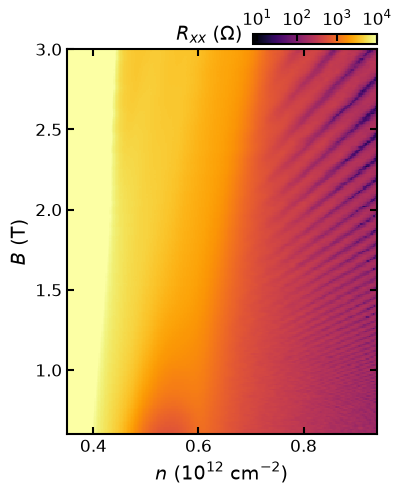

In [7]:
def plot_landau_fan(fig, ax, norm, cmap="viridis"):
    file = 1840
    contact = 3 # choose which contact pair to plot = 1,2,3  
    data = sl.pload(file_path, file)
    ys = data['ys'][0]
    zs = data[f'sr830_{contact}_X']/data['sr830_4_X']
    zs = zs
    
    Vtgs = data['xs'][0]
    Vbgs = data['xs'][1]
    xs, _ = calculate_n_D(Vtgs, Vbgs, dtg=rmg19['default']['dtg'], dbg=rmg19['default']['dbg'])
    plot = ax.pcolormesh(xs, ys, zs, norm=norm, cmap=cmap, rasterized=True)
    ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
    ax.set_ylabel(r'$B$ (T)')
    ax.set_xlim(0.35, 0.94)
    #ax.set_ylim(0.8, 5)
    ax.set_ylim(0.6, 3)
    #ax.plot([0.50, 0.50], [0.8,1.1], color="white", ls="--")
    #ax.plot([0.60, 0.60], [0.8,1.1], color="white", ls="--")
    #ax.text(0.52, 0.9, "CSC", color="white",fontweight="bold")
    ax.xaxis.set_major_locator(plt.MaxNLocator(3))
    ax.yaxis.set_major_locator(plt.MaxNLocator(5))
    return plot


fig = plt.figure(figsize=(4,5))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=100, vmin=1, vmax=1E4)
plot = plot_landau_fan(fig, ax, norm, "inferno")

cax = fig.add_axes([0.59, 0.89, 0.31, 0.02])
cb = plt.colorbar(plot, cax=cax, ticks=SymmetricalLogLocator(base=10, linthresh=10), orientation='horizontal', shrink=0.3, anchor=(1., 0.9), pad=0.01, aspect=5)
cb.ax.set_xlabel(r'$R_{xx}$ ($\Omega$)', labelpad=-22, x=-0.35)
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')  

#ax.xaxis.set_major_locator(plt.MaxNLocator(6))
#ax.set_xlim(0.65, 0.84)
save_fig(fig, 'fig3_landau_fan')

# b - Detrended Landau fan

<>:29: SyntaxWarning: invalid escape sequence '\D'
<>:29: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_767732/818604014.py:29: SyntaxWarning: invalid escape sequence '\D'
  cb.ax.annotate('$\Delta R_{xx} (\Omega)$', xy=(-0.10, 0.5), xycoords='axes fraction',


['/home/aaron/Fermiology-and-the-cCSC/figs/fig3_landau_fan_detrended.pdf',
 '/home/aaron/Fermiology-and-the-cCSC/figs/fig3_landau_fan_detrended.png']

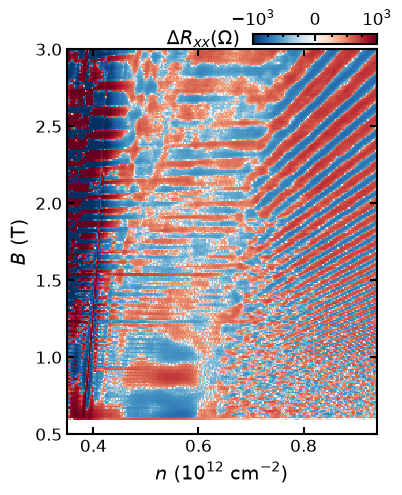

In [8]:
def plot_landau_fan_detrend(fig, ax, norm, cmap="viridis"):
    analyzer = Lf_analysis(1840, contact=2)
    n_vec = analyzer.density
    B_vec, Rxx_detrended = analyzer.get_bg_subtracted_data(bg_method=detrend_butterworth, \
                                              bg_method_params={'cutoff': None, 'order' : 4}, 
                                              blims=(0.2, 5), return_bg=False)
    
    plot = ax.pcolormesh(n_vec, B_vec, Rxx_detrended, norm=norm, cmap=cmap, rasterized=True)
    ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
    ax.set_ylabel(r'$B$ (T)')
    ax.set_xlim(0.35, 0.94)
    #ax.axvline(0.5, ls="--", color="white")
    #ax.axvline(0.62, ls="--", color="white")
    ax.set_ylim(0.5, 3)
    ax.xaxis.set_major_locator(plt.MaxNLocator(3))
    ax.yaxis.set_major_locator(plt.MaxNLocator(5))
    return plot


fig = plt.figure(figsize=(4,5))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=1, vmin=-1e3, vmax=1E3)
plot = plot_landau_fan_detrend(fig, ax, norm, "RdBu_r")

cax = fig.add_axes([0.59, 0.89, 0.31, 0.02])
cb = plt.colorbar(plot, cax=cax, ticks=SymmetricalLogLocator(base=10, linthresh=10), orientation='horizontal', shrink=0.3, anchor=(1., 0.9), pad=0.01, aspect=5)
cb = plt.colorbar(plot, cax=cax, ticks=[-1000, 0, 1000], \
                  orientation='horizontal')
cb.ax.annotate('$\Delta R_{xx} (\Omega)$', xy=(-0.10, 0.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top') 
cb.set_ticklabels(['$-10^3$', '$0$', '$10^3$'])
save_fig(fig, 'fig3_landau_fan_detrended')

# Detrend for various D

In [9]:
file_ids = [1885, 1957, 1840, 1958, 1886, 1888]

/tmp/ipykernel_767732/711788671.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


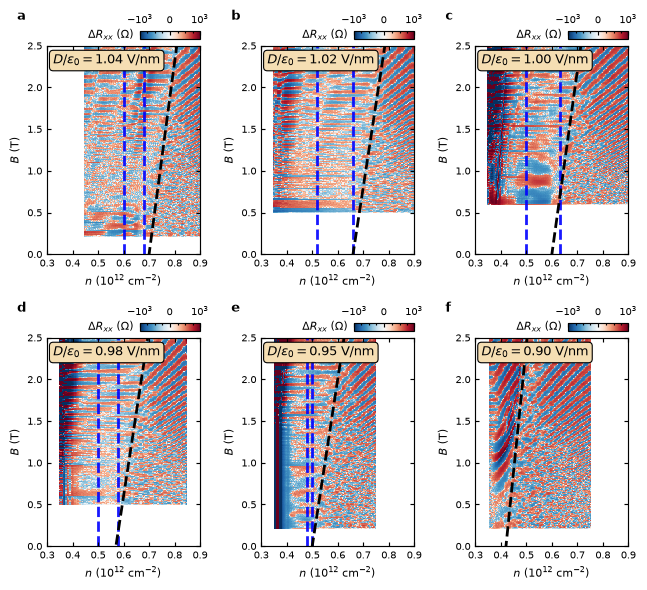

In [12]:
update_rc_params('paper')  # paper style for this final figure

def plot_landau_fan_detrend_file(fig, ax, file, norm, cmap="viridis"):
    analyzer = Lf_analysis(file, contact=2)
    n_vec = analyzer.density
    B_vec, Rxx_detrended = analyzer.get_bg_subtracted_data(bg_method=detrend_butterworth,
                                                           bg_method_params={'cutoff': None, 'order': 4},
                                                           blims=(0.2, 5), return_bg=False)
    plot = ax.pcolormesh(n_vec, B_vec, Rxx_detrended, norm=norm, cmap=cmap, rasterized=True)
    ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
    ax.set_ylabel(r'$B$ (T)')
    ax.set_xlim(0.35, 0.94)
    ax.set_ylim(0, 3)
    ax.xaxis.set_major_locator(plt.MaxNLocator(7))
    ax.yaxis.set_major_locator(plt.MaxNLocator(5))
    return plot


# ── Global colorbar geometry ──────────────────────────────────────────────────
cb_width = 0.08          # colorbar width in figure fraction
cb_height_inches = 0.08  # colorbar height in physical inches (fixed across fig sizes)
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(7.5, 6.5))
gs = GridSpec(2, 3, figure=fig,   
                       width_ratios=[0.33, 0.33, 0.33],
                       height_ratios=[1, 1],
                       hspace=0.4, wspace=0.4)

cb_height_frac = cb_height_inches / fig.get_size_inches()[1]

ax_locs = [[0,0], [0,1], [0,2], [1,0], [1,1], [1,2]]
panel_labels = ["a", "b", "c", "d", "e", "f"]
Ds = [1.04, 1.02, 1.0, 0.98, 0.95, 0.9]
slope_vec = [23, 20, 22, 20, 20, 30]
n0_vec = [0.70, 0.66, 0.60, 0.57, 0.5, 0.42]

axarr = []
for ind_ax, file in enumerate(file_ids):
    ax = fig.add_subplot(gs[ax_locs[ind_ax][0], ax_locs[ind_ax][1]])
    axarr.append(ax)
    norm = colors.SymLogNorm(linthresh=1, vmin=-1e3, vmax=1E3)
    plot = plot_landau_fan_detrend_file(fig, ax, file, norm, "RdBu_r")

    ax.text(0.04, 0.96, r'$D/\epsilon_0 = {:.2f}$ V/nm'.format(Ds[ind_ax]),
            transform=ax.transAxes, ha='left', va='top', color='k',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat',
                      edgecolor='k', linewidth=0.8, alpha=1))

    fig.canvas.draw()
    pos = ax.get_position()
    label_spacer = 0.04
    fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, panel_labels[ind_ax],
             fontweight='bold')

    cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, cb_height_frac])
    cb = plt.colorbar(plot, cax=cax, ticks=[-1000, 0, 1000], orientation='horizontal')
    cb.ax.annotate(r'$\Delta R_{xx}$ ($\Omega$)', xy=(-0.10, 0.5), xycoords='axes fraction',
                   ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
    cb.ax.xaxis.set_ticks_position('top')
    cb.ax.xaxis.set_label_position('top') 
    cb.set_ticklabels([r'$-10^3$', '$0$', r'$10^3$'])

    ax.set_ylim(0.0, 2.5)
    ax.set_xlim(0.3, 0.9)
    
    analyzer = Lf_analysis(file, contact=2)
    n_vec = analyzer.density
    ax.plot(n_vec, slope_vec[ind_ax]*(n_vec - n0_vec[ind_ax]), color="black", ls="--", lw=2)


sc_ranges = [
(0.60, 0.68),   # brown
(0.52, 0.66),   # purple
(0.50, 0.63),   # red
(0.50, 0.58),   # green
(0.48, 0.50),   # orange
(0.42, 0.42),   # blue — no clear SC pocket
]
for ind, (n_lo, n_hi) in enumerate(sc_ranges):
    # skip last one
    if ind != len(sc_ranges) - 1:
        axarr[ind].axvline(n_lo, color="blue", alpha=0.9, zorder=1, ls="--", lw=2)
        axarr[ind].axvline(n_hi, color="blue", alpha=0.9, zorder=1, ls="--", lw=2)

plt.tight_layout()
plt.show()
fig.savefig("edfig-detrend-vs-D.pdf", dpi=600, bbox_inches='tight',
            pad_inches=0.02, transparent=False)

update_rc_params('talk')  # restore presentation default

/tmp/ipykernel_767732/4128761057.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


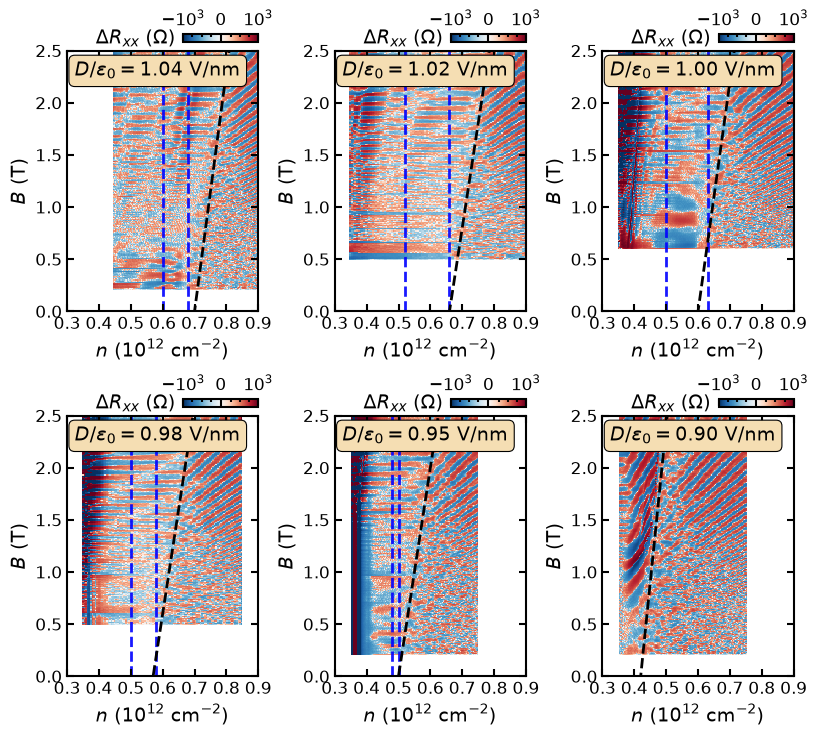

['/home/aaron/Fermiology-and-the-cCSC/figs/fig3_detrend_vs_D.pdf',
 '/home/aaron/Fermiology-and-the-cCSC/figs/fig3_detrend_vs_D.png']

In [13]:
update_rc_params('talk')  # paper style for this final figure

def plot_landau_fan_detrend_file(fig, ax, file, norm, cmap="viridis"):
    analyzer = Lf_analysis(file, contact=2)
    n_vec = analyzer.density
    B_vec, Rxx_detrended = analyzer.get_bg_subtracted_data(bg_method=detrend_butterworth,
                                                           bg_method_params={'cutoff': None, 'order': 4},
                                                           blims=(0.2, 5), return_bg=False)
    plot = ax.pcolormesh(n_vec, B_vec, Rxx_detrended, norm=norm, cmap=cmap, rasterized=True)
    ax.set_xlabel(r'$n$ ($10^{12}$ cm$^{-2}$)')
    ax.set_ylabel(r'$B$ (T)')
    ax.set_xlim(0.35, 0.94)
    ax.set_ylim(0, 3)
    ax.xaxis.set_major_locator(plt.MaxNLocator(7))
    ax.yaxis.set_major_locator(plt.MaxNLocator(5))
    return plot


# ── Global colorbar geometry ──────────────────────────────────────────────────
cb_width = 0.08          # colorbar width in figure fraction
cb_height_inches = 0.08  # colorbar height in physical inches (fixed across fig sizes)
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(7.5*1.25, 6.5*1.25))
gs = GridSpec(2, 3, figure=fig,   
                       width_ratios=[0.33, 0.33, 0.33],
                       height_ratios=[1, 1],
                       hspace=0.4, wspace=0.4)

cb_height_frac = cb_height_inches / fig.get_size_inches()[1]

ax_locs = [[0,0], [0,1], [0,2], [1,0], [1,1], [1,2]]
panel_labels = ["a", "b", "c", "d", "e", "f"]
Ds = [1.04, 1.02, 1.0, 0.98, 0.95, 0.9]
slope_vec = [23, 20, 22, 20, 20, 30]
n0_vec = [0.70, 0.66, 0.60, 0.57, 0.5, 0.42]

axarr = []
for ind_ax, file in enumerate(file_ids):
    ax = fig.add_subplot(gs[ax_locs[ind_ax][0], ax_locs[ind_ax][1]])
    axarr.append(ax)
    norm = colors.SymLogNorm(linthresh=1, vmin=-1e3, vmax=1E3)
    plot = plot_landau_fan_detrend_file(fig, ax, file, norm, "RdBu_r")

    ax.text(0.04, 0.96, r'$D/\epsilon_0 = {:.2f}$ V/nm'.format(Ds[ind_ax]),
            transform=ax.transAxes, ha='left', va='top', color='k',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat',
                      edgecolor='k', linewidth=0.8, alpha=1))

    fig.canvas.draw()
    pos = ax.get_position()
    label_spacer = 0.04
    # fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, panel_labels[ind_ax],
            #  fontweight='bold')

    cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, cb_height_frac])
    cb = plt.colorbar(plot, cax=cax, ticks=[-1000, 0, 1000], orientation='horizontal')
    cb.ax.annotate(r'$\Delta R_{xx}$ ($\Omega$)', xy=(-0.10, 0.5), xycoords='axes fraction',
                   ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
    cb.ax.xaxis.set_ticks_position('top')
    cb.ax.xaxis.set_label_position('top') 
    cb.set_ticklabels([r'$-10^3$', '$0$', r'$10^3$'])

    ax.set_ylim(0.0, 2.5)
    ax.set_xlim(0.3, 0.9)
    
    analyzer = Lf_analysis(file, contact=2)
    n_vec = analyzer.density
    ax.plot(n_vec, slope_vec[ind_ax]*(n_vec - n0_vec[ind_ax]), color="black", ls="--", lw=2)


sc_ranges = [
(0.60, 0.68),   # brown
(0.52, 0.66),   # purple
(0.50, 0.63),   # red
(0.50, 0.58),   # green
(0.48, 0.50),   # orange
(0.42, 0.42),   # blue — no clear SC pocket
]
for ind, (n_lo, n_hi) in enumerate(sc_ranges):
    # skip last one
    if ind != len(sc_ranges) - 1:
        axarr[ind].axvline(n_lo, color="blue", alpha=0.9, zorder=1, ls="--", lw=2)
        axarr[ind].axvline(n_hi, color="blue", alpha=0.9, zorder=1, ls="--", lw=2)

plt.tight_layout()
plt.show()
# fig.savefig("fig-detrend-vs-D.pdf", dpi=600, bbox_inches='tight',
            # pad_inches=0.02, transparent=False)
save_fig(fig, 'fig3_detrend_vs_D')
    